In [4]:
import pymupdf
import nltk
import sentence_transformers
import faiss
import streamlit
import numpy as np
import pandas as pd

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
import os

pdfPath = os.path.join(
    "data",
    "study_material",
    "NLP_Study_Notes_for_RAG_Test.pdf"
)

print("PDF exists:", os.path.exists(pdfPath))

PDF exists: True


In [ ]:
import pymupdf

document = pymupdf.open(pdfPath)
s
pages = []

for pageNumber, page in enumerate(document):
    text = page.get_text()

    pages.append({
        "page": pageNumber + 1,
        "text": text
    })

document.close()

print("Total pages:", len(pages))
print("\nFirst page content:\n")
print(pages[0]["text"][:1000])

Total pages: 6

First page content:

NLP Study Notes — Intelligent Study Assistant
Page 1
Natural Language Processing (NLP)
Study Notes for Testing an Intelligent Study Assistant
These notes cover basic NLP concepts, text preprocessing, embeddings, semantic search, and
Retrieval-Augmented Generation (RAG). The document is intentionally text-based so it can be used
to test PDF text extraction in a student project.
Learning objectives
• Explain what NLP is and identify common applications.
• Describe tokenization, stop-word removal, stemming, and lemmatization.
• Understand the difference between keyword search and semantic search.
• Explain how embeddings, vector databases, retrieval, and RAG work together.



In [7]:
import re
import nltk

from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

rawText = "\n".join(page["text"] for page in pages)

cleanText = re.sub(r"\s+", " ", rawText).strip()

tokens = word_tokenize(cleanText)

print("Original text length:", len(rawText))
print("Clean text length:", len(cleanText))
print("Total tokens:", len(tokens))
print("\nFirst 30 tokens:")
print(tokens[:30])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Original text length: 8143
Clean text length: 8137
Total tokens: 1465

First 30 tokens:
['NLP', 'Study', 'Notes', '—', 'Intelligent', 'Study', 'Assistant', 'Page', '1', 'Natural', 'Language', 'Processing', '(', 'NLP', ')', 'Study', 'Notes', 'for', 'Testing', 'an', 'Intelligent', 'Study', 'Assistant', 'These', 'notes', 'cover', 'basic', 'NLP', 'concepts', ',']


In [8]:
chunkSize = 800
overlap = 200

chunks = []

for page in pages:
    text = re.sub(r"\s+", " ", page["text"]).strip()

    start = 0

    while start < len(text):
        end = start + chunkSize
        chunkText = text[start:end]

        if chunkText.strip():
            chunks.append({
                "page": page["page"],
                "text": chunkText
            })

        start += chunkSize - overlap

print("Total chunks:", len(chunks))
print("\nFirst chunk:\n")
print(chunks[0]["text"])
print("\nSource page:", chunks[0]["page"])

Total chunks: 18

First chunk:

NLP Study Notes — Intelligent Study Assistant Page 1 Natural Language Processing (NLP) Study Notes for Testing an Intelligent Study Assistant These notes cover basic NLP concepts, text preprocessing, embeddings, semantic search, and Retrieval-Augmented Generation (RAG). The document is intentionally text-based so it can be used to test PDF text extraction in a student project. Learning objectives • Explain what NLP is and identify common applications. • Describe tokenization, stop-word removal, stemming, and lemmatization. • Understand the difference between keyword search and semantic search. • Explain how embeddings, vector databases, retrieval, and RAG work together.

Source page: 1


In [9]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

chunkTexts = [chunk["text"] for chunk in chunks]

embeddings = model.encode(
    chunkTexts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Number of chunks:", len(chunkTexts))
print("Embedding shape:", embeddings.shape)
print("First embedding:")
print(embeddings[0][:10])

Batches: 100%|██████████| 1/1 [00:04<00:00,  4.35s/it]

Number of chunks: 18
Embedding shape: (18, 384)
First embedding:
[-0.04002393  0.06215856  0.04244169  0.04906223  0.0273727  -0.01680076
  0.00241788  0.02107872 -0.06082661 -0.00757649]


In [10]:
import faiss
import numpy as np

embeddingDimension = embeddings.shape[1]

vectorIndex = faiss.IndexFlatIP(embeddingDimension)

normalizedEmbeddings = embeddings.copy().astype("float32")
faiss.normalize_L2(normalizedEmbeddings)

vectorIndex.add(normalizedEmbeddings)

print("FAISS index created successfully!")
print("Total vectors stored:", vectorIndex.ntotal)
print("Vector dimensions:", vectorIndex.d)

FAISS index created successfully!
Total vectors stored: 18
Vector dimensions: 384


In [11]:
query = "What is Retrieval-Augmented Generation?"

queryEmbedding = model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")

faiss.normalize_L2(queryEmbedding)

scores, indices = vectorIndex.search(queryEmbedding, k=3)

for rank, (score, index) in enumerate(
    zip(scores[0], indices[0]), start=1
):
    print(f"\nResult {rank} | Similarity: {score:.4f}")
    print("Source page:", chunks[index]["page"])
    print(chunks[index]["text"][:400])


Result 1 | Similarity: 0.5965
Source page: 5
NLP Study Notes — Intelligent Study Assistant Page 5 4. Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation. Instead of relying only on information learned during model training, a RAG system retrieves relevant passages from a supplied collection and uses them as context when generating an answer. Main st

Result 2 | Similarity: 0.4041
Source page: 1
 • Explain how embeddings, vector databases, retrieval, and RAG work together.

Result 3 | Similarity: 0.3748
Source page: 6
t context, or generate an incorrect answer. Scanned PDFs may require OCR if they contain images rather than selectable text. Embedding models and language models may need an initial download, and generation may require a separate model or service. Users should verify important answers against the original study material. Quick revision questions • What is the difference between s

TotalPhysicalMemory  

17101824000          






In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

chunkTexts = [chunk["text"] for chunk in chunks]

tfidfVectorizer = TfidfVectorizer()
tfidfMatrix = tfidfVectorizer.fit_transform(chunkTexts)

query = "What is Retrieval-Augmented Generation?"
queryVector = tfidfVectorizer.transform([query])

similarityScores = cosine_similarity(queryVector, tfidfMatrix)[0]

topIndices = similarityScores.argsort()[::-1][:3]

for rank, index in enumerate(topIndices, start=1):
    print(f"\nResult {rank}")
    print("Similarity:", round(similarityScores[index], 4))
    print("Source page:", chunks[index]["page"])
    print(chunks[index]["text"][:300])


Result 1
Similarity: 0.2831
Source page: 5
NLP Study Notes — Intelligent Study Assistant Page 5 4. Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation. Instead of relying only on information learned during model training, a RAG system retrieves rele

Result 2
Similarity: 0.2295
Source page: 1
NLP Study Notes — Intelligent Study Assistant Page 1 Natural Language Processing (NLP) Study Notes for Testing an Intelligent Study Assistant These notes cover basic NLP concepts, text preprocessing, embeddings, semantic search, and Retrieval-Augmented Generation (RAG). The document is intentionally

Result 3
Similarity: 0.1609
Source page: 6
t context, or generate an incorrect answer. Scanned PDFs may require OCR if they contain images rather than selectable text. Embedding models and language models may need an initial download, and generation may require a separate model or service. Users should verif

In [14]:
testQueries = [
    "What is Retrieval-Augmented Generation?",
    "What is the role of embeddings?",
    "Why is text preprocessing needed?",
    "How can retrieval quality be evaluated?",
    "What are the limitations of a RAG system?"
]

for query in testQueries:
    print("\n" + "=" * 70)
    print("QUERY:", query)

    queryVector = tfidfVectorizer.transform([query])
    similarityScores = cosine_similarity(queryVector, tfidfMatrix)[0]
    topIndices = similarityScores.argsort()[::-1][:1]

    print("\nTF-IDF Result:")
    for index in topIndices:
        print("Page:", chunks[index]["page"])
        print("Score:", round(similarityScores[index], 4))
        print("Text:", chunks[index]["text"][:200])

    queryEmbedding = model.encode(
        [query], convert_to_numpy=True
    ).astype("float32")

    faiss.normalize_L2(queryEmbedding)
    scores, indices = vectorIndex.search(queryEmbedding, k=1)

    print("\nEmbedding + FAISS Result:")
    print("Page:", chunks[indices[0][0]]["page"])
    print("Score:", round(float(scores[0][0]), 4))
    print("Text:", chunks[indices[0][0]]["text"][:200])


QUERY: What is Retrieval-Augmented Generation?

TF-IDF Result:
Page: 5
Score: 0.2831
Text: NLP Study Notes — Intelligent Study Assistant Page 5 4. Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generatio

Embedding + FAISS Result:
Page: 5
Score: 0.5965
Text: NLP Study Notes — Intelligent Study Assistant Page 5 4. Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generatio

QUERY: What is the role of embeddings?

TF-IDF Result:
Page: 6
Score: 0.209
Text: t context, or generate an incorrect answer. Scanned PDFs may require OCR if they contain images rather than selectable text. Embedding models and language models may need an initial download, and gene

Embedding + FAISS Result:
Page: 1
Score: 0.6352
Text:  • Explain how embeddings, vector databases, retrieval, and RAG work together.

QUERY: Why is text preprocessing

In [15]:
relevantPages = {
    "What is Retrieval-Augmented Generation?": [5],
    "What is the role of embeddings?": [2],
    "Why is text preprocessing needed?": [3],
    "How can retrieval quality be evaluated?": [6],
    "What are the limitations of a RAG system?": [6]
}

tfidfCorrect = 0
faissCorrect = 0

for query, expectedPages in relevantPages.items():
    queryVector = tfidfVectorizer.transform([query])
    scores = cosine_similarity(queryVector, tfidfMatrix)[0]
    tfidfPage = chunks[scores.argmax()]["page"]

    queryEmbedding = model.encode(
        [query], convert_to_numpy=True
    ).astype("float32")

    faiss.normalize_L2(queryEmbedding)
    _, indices = vectorIndex.search(queryEmbedding, k=1)
    faissPage = chunks[indices[0][0]]["page"]

    tfidfHit = tfidfPage in expectedPages
    faissHit = faissPage in expectedPages

    tfidfCorrect += int(tfidfHit)
    faissCorrect += int(faissHit)

    print("\nQuery:", query)
    print("Expected page(s):", expectedPages)
    print("TF-IDF:", tfidfPage, "| Relevant:", tfidfHit)
    print("FAISS:", faissPage, "| Relevant:", faissHit)

print("\nTF-IDF Precision@1:", round(tfidfCorrect / len(relevantPages), 2))
print("FAISS Precision@1:", round(faissCorrect / len(relevantPages), 2))


Query: What is Retrieval-Augmented Generation?
Expected page(s): [5]
TF-IDF: 5 | Relevant: True
FAISS: 5 | Relevant: True

Query: What is the role of embeddings?
Expected page(s): [2]
TF-IDF: 6 | Relevant: False
FAISS: 1 | Relevant: False

Query: Why is text preprocessing needed?
Expected page(s): [3]
TF-IDF: 3 | Relevant: True
FAISS: 3 | Relevant: True

Query: How can retrieval quality be evaluated?
Expected page(s): [6]
TF-IDF: 1 | Relevant: False
FAISS: 6 | Relevant: True

Query: What are the limitations of a RAG system?
Expected page(s): [6]
TF-IDF: 6 | Relevant: True
FAISS: 1 | Relevant: False

TF-IDF Precision@1: 0.6
FAISS Precision@1: 0.6


In [16]:
import re

query = "What is Retrieval-Augmented Generation?"

queryEmbedding = model.encode(
    [query], convert_to_numpy=True
).astype("float32")

faiss.normalize_L2(queryEmbedding)
scores, indices = vectorIndex.search(queryEmbedding, k=3)

for index in indices[0]:
    print("\nSource page:", chunks[index]["page"])

    sentences = re.split(
        r"(?<=[.!?])\s+",
        chunks[index]["text"]
    )

    for sentence in sentences:
        if sentence.strip():
            print("-", sentence.strip())


Source page: 5
- NLP Study Notes — Intelligent Study Assistant Page 5 4.
- Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation.
- Instead of relying only on information learned during model training, a RAG system retrieves relevant passages from a supplied collection and uses them as context when generating an answer.
- Main stages of a RAG system • Document loading: read study material from PDF or other supported formats.
- • Text extraction and cleaning: obtain readable text and remove extraction noise where appropriate.
- • Chunking: divide long documents into smaller passages so that relevant sections can be retrieved.
- • Embedding: convert each passage into a numerical vector.
- • Indexing: store vectors in a searchable i

Source page: 1
- • Explain how embeddings, vector databases, retrieval, and RAG work together.

Source page: 6
- t context, or generate an incorrect answer.
- Scanned

In [19]:
import re

query = "What is Retrieval-Augmented Generation?"

queryEmbedding = model.encode(
    [query], convert_to_numpy=True
).astype("float32")

faiss.normalize_L2(queryEmbedding)
scores, indices = vectorIndex.search(queryEmbedding, k=3)

answer = None
sourcePage = None

for index in indices[0]:
    text = chunks[index]["text"]
    sentences = re.split(r"(?<=[.!?])\s+", text)

    for sentence in sentences:
        sentence = sentence.strip()

        match = re.search(
            r"Retrieval-Augmented Generation\s*\(RAG\)\s+is an approach that combines information retrieval with text generation\.",
            sentence,
            re.IGNORECASE
        )

        if match:
            answer = match.group(0)
            sourcePage = chunks[index]["page"]
            break

    if answer:
        break

print("Question:", query)
print("\nAnswer:", answer if answer else "No suitable answer found.")
print("Source page:", sourcePage)
print("Retrieval similarity:", round(float(scores[0][0]), 4))

Question: What is Retrieval-Augmented Generation?

Answer: Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation.
Source page: 5
Retrieval similarity: 0.5965


In [29]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def generateAnswer(query):
    queryLower = query.lower()

    queryEmbedding = model.encode(
        [query], convert_to_numpy=True
    ).astype("float32")

    faiss.normalize_L2(queryEmbedding)
    _, indices = vectorIndex.search(queryEmbedding, k=5)

    candidates = []
    candidatePages = []

    for index in indices[0]:
        text = chunks[index]["text"]

        sentences = re.split(r"(?<=[.!?])\s+", text)

        for sentence in sentences:
            sentence = sentence.strip()
            sentence = re.sub(r"^[•\-]\s*", "", sentence)

            if len(sentence.split()) < 8:
                continue

            if sentence.endswith(":"):
                continue

            candidates.append(sentence)
            candidatePages.append(chunks[index]["page"])

    if not candidates:
        return "No suitable answer found.", None

    vectorizer = TfidfVectorizer(stop_words="english")
    matrix = vectorizer.fit_transform(candidates + [query])

    scores = cosine_similarity(matrix[-1], matrix[:-1])[0]

    if "evaluat" in queryLower or "retrieval quality" in queryLower:
        keywords = [
            "evaluation", "precision", "relevant passages",
            "answer correctness", "faithfulness", "response time"
        ]

        for i, sentence in enumerate(candidates):
            if any(word in sentence.lower() for word in keywords):
                scores[i] += 0.15

    bestIndex = scores.argmax()

    return candidates[bestIndex], candidatePages[bestIndex]

In [24]:
testQueries = [
    "What is the role of embeddings?",
    "Why is text preprocessing needed?",
    "How can retrieval quality be evaluated?",
    "What are the limitations of a RAG system?"
]

for query in testQueries:
    answer, sourcePage = generateAnswer(query)
    print("\nQuestion:", query)
    print("Answer:", answer)
    print("Source page:", sourcePage)


Question: What is the role of embeddings?
Answer: It is commonly used to compare text embeddings during semantic search.
Source page: 4

Question: Why is text preprocessing needed?
Answer: Text Preprocessing Text preprocessing prepares raw text for analysis.
Source page: 3

Question: How can retrieval quality be evaluated?
Answer: Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation.
Source page: 5

Question: What are the limitations of a RAG system?
Answer: Limitations and responsible use A RAG system can retrieve the wrong passage, miss important context, or generate an incorrect answer.
Source page: 6


In [28]:
for page in pages:
    if page["page"] == 6:
        print(page["text"])

NLP Study Notes — Intelligent Study Assistant
Page 6
5. Evaluating a Study Assistant
Evaluation helps determine whether the system retrieves relevant information and answers questions
reliably. A project should use a small set of test questions whose expected answers can be checked
against the source notes.
Possible evaluation measures
Retrieval relevance: manually check whether the retrieved passages contain information needed to
answer the question. Precision at k can measure the fraction of the top k retrieved passages judged
relevant.
Answer correctness: compare generated answers with reference answers or a marking rubric. A
human reviewer can check factual accuracy, completeness, and whether the answer is supported by
the retrieved source.
Faithfulness: check whether the answer is supported by the retrieved passages rather than
introducing unsupported claims. Displaying page references makes manual verification easier.
Response time: record how long the system takes to retrieve pa

In [31]:
query = "How can retrieval quality be evaluated?"
answer, sourcePage = generateAnswer(query)

print("Question:", query)
print("Answer:", answer)
print("Source page:", sourcePage)

Question: How can retrieval quality be evaluated?
Answer: Possible evaluation measures Retrieval relevance: manually check whether the retrieved passages contain information needed to answer the question.
Source page: 6


In [38]:
%matplotlib inline

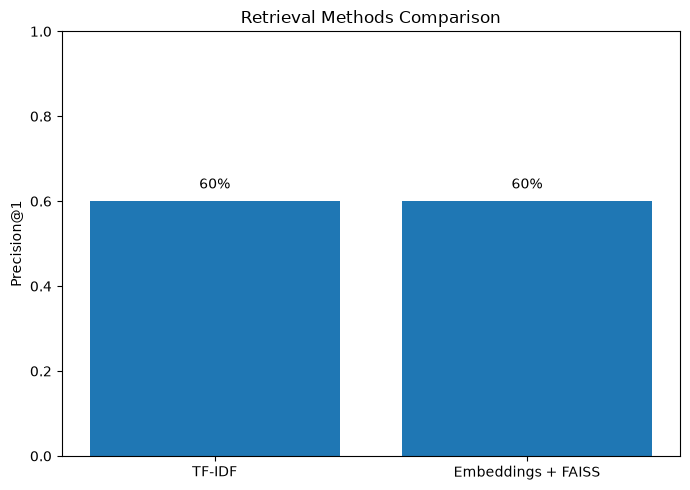

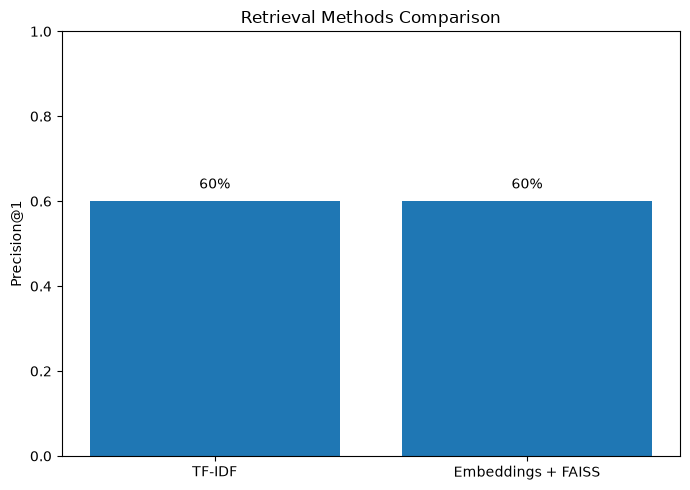

In [39]:
import matplotlib.pyplot as plt

methods = ["TF-IDF", "Embeddings + FAISS"]
precisionScores = [
    tfidfCorrect / len(relevantPages),
    faissCorrect / len(relevantPages)
]

plt.figure(figsize=(7, 5))
bars = plt.bar(methods, precisionScores)

plt.title("Retrieval Methods Comparison")
plt.ylabel("Precision@1")
plt.ylim(0, 1)

for bar, score in zip(bars, precisionScores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.03,
        f"{score:.0%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

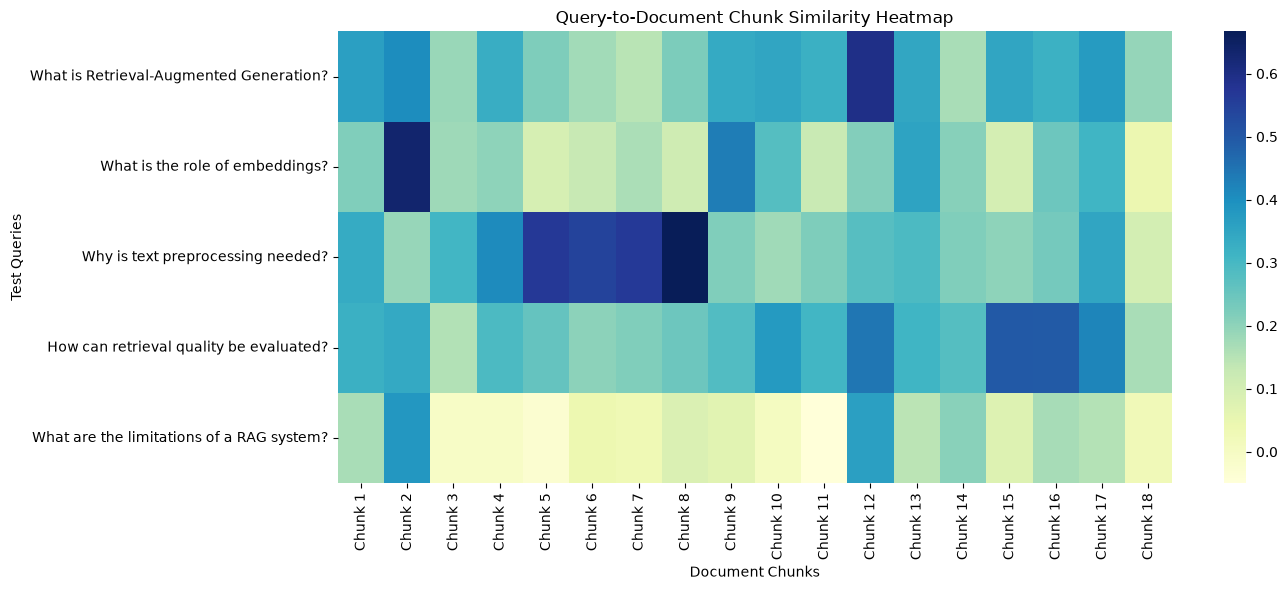

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

queryTexts = list(relevantPages.keys())

queryEmbeddings = model.encode(
    queryTexts,
    convert_to_numpy=True
).astype("float32")

import faiss
faiss.normalize_L2(queryEmbeddings)

similarityMatrix = queryEmbeddings @ embeddings.T

plt.figure(figsize=(14, 6))

sns.heatmap(
    similarityMatrix,
    cmap="YlGnBu",
    xticklabels=[f"Chunk {i + 1}" for i in range(len(chunks))],
    yticklabels=queryTexts,
    annot=False
)

plt.title("Query-to-Document Chunk Similarity Heatmap")
plt.xlabel("Document Chunks")
plt.ylabel("Test Queries")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [44]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [46]:
testQueries = [
    "What is Retrieval-Augmented Generation?",
    "What is the role of embeddings?",
    "Why is text preprocessing needed?",
    "How can retrieval quality be evaluated?",
    "What are the limitations of a RAG system?"
]

for query in testQueries:
    answer, page = generateAnswer(query)

    print("Question:", query)
    print("Answer:", answer)
    print("Source Page:", page)
    print("-" * 80)

Question: What is Retrieval-Augmented Generation?
Answer: Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation.
Source Page: 5
--------------------------------------------------------------------------------
Question: What is the role of embeddings?
Answer: What role does FAISS play in a vector-search pipeline?
Source Page: 6
--------------------------------------------------------------------------------
Question: Why is text preprocessing needed?
Answer: Text Preprocessing Text preprocessing prepares raw text for analysis.
Source Page: 3
--------------------------------------------------------------------------------
Question: How can retrieval quality be evaluated?
Answer: Possible evaluation measures Retrieval relevance: manually check whether the retrieved passages contain information needed to answer the question.
Source Page: 6
------------------------------------------------------------